# Toy Models Overview

This notebook demonstrates all five toy models available in `psiphy.toy_models`.
Each model exposes the same minimal interface:

```python
theta = model.sample_prior()       # draw from prior
x     = model.simulate(theta)      # forward simulation
lp    = model.log_prob(theta, x)   # log-likelihood (None if intractable)
```

Models with an analytic likelihood (`log_prob` is not None) can be used directly
with MCMC samplers (e.g. emcee, dynesty) as well as Fisher forecasting.
Models with an intractable likelihood are intended for likelihood-free / SBI methods.

Models covered:
1. **GaussianSignal** — 1-D Gaussian, analytic posterior
2. **NoisyLine** — linear model with Gaussian noise, analytic likelihood
3. **MA2Model** — Moving Average(2) process, standard LFI benchmark
4. **PowerLawSpectrum** — CMB-like power-law spectrum, analytic likelihood
5. **LotkaVolterra** — predator-prey ODE, analytic Gaussian likelihood

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from psiphy.toy_models import GaussianSignal, NoisyLine, MA2Model, PowerLawSpectrum

rng = np.random.default_rng(42)
np.random.seed(42)

---
## 1  GaussianSignal

Parameterised 1-D Gaussian: $x_i \sim \mathcal{N}(\mu, \sigma^2)$.

Parameters: `theta = [mean, sigma]`.

Analytic likelihood makes this suitable for **MCMC**, Fisher forecasting, and SBI sanity checks.

In [2]:
gs = GaussianSignal(N=40)
theta_true = np.array([1.5, 0.8])   # [mean, sigma]

x_obs = gs.simulate(theta_true)
print(f"theta_true : {theta_true}")
print(f"x_obs      : mean={x_obs.mean():.3f}, std={x_obs.std():.3f}")
print(f"log_prob   : {gs.log_prob(theta_true, x_obs):.2f}")

theta_true : [1.5 0.8]
x_obs      : mean=1.325, std=0.753
log_prob   : -46.49


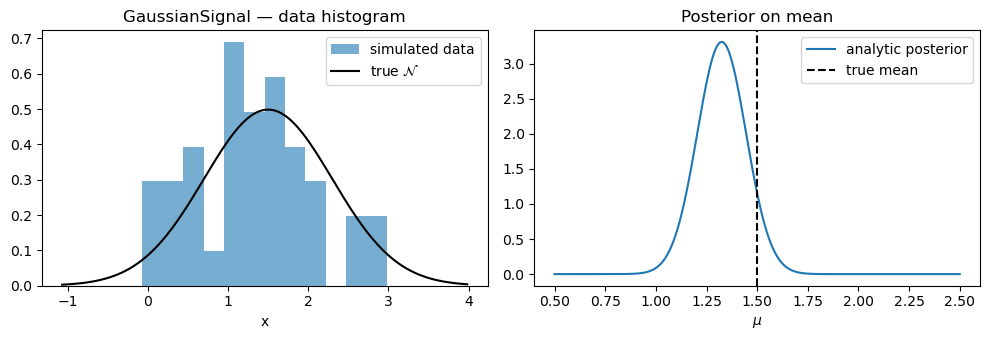

In [3]:
# Analytic posterior on mean (sigma plugged in)
post_mean, post_sigma = gs.analytic_posterior(x_obs)

mu_grid = np.linspace(0.5, 2.5, 400)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(x_obs, bins=12, density=True, alpha=0.6, label="simulated data")
x_plot = np.linspace(x_obs.min() - 1, x_obs.max() + 1, 300)
axes[0].plot(x_plot, norm.pdf(x_plot, *theta_true), "k-", label=r"true $\mathcal{N}$")
axes[0].set(xlabel="x", title="GaussianSignal — data histogram")
axes[0].legend()

axes[1].plot(mu_grid, norm.pdf(mu_grid, post_mean, post_sigma), label="analytic posterior")
axes[1].axvline(theta_true[0], ls="--", c="k", label="true mean")
axes[1].set(xlabel=r"$\mu$", title="Posterior on mean")
axes[1].legend()

plt.tight_layout()
plt.show()

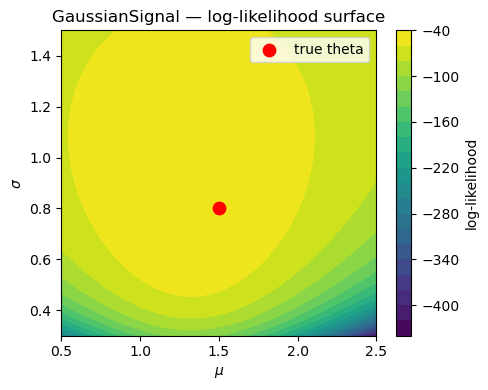

In [4]:
# Log-likelihood surface over (mean, sigma)
mean_grid  = np.linspace(0.5, 2.5, 80)
sigma_grid = np.linspace(0.3, 1.5, 80)
MM, SS = np.meshgrid(mean_grid, sigma_grid)

loglike = np.array([
    gs.log_prob([m, s], x_obs)
    for m, s in zip(MM.ravel(), SS.ravel())
]).reshape(MM.shape)

fig, ax = plt.subplots(figsize=(5, 4))
c = ax.contourf(MM, SS, loglike, levels=20, cmap="viridis")
plt.colorbar(c, ax=ax, label="log-likelihood")
ax.scatter(*theta_true, c="red", zorder=5, s=80, label="true theta")
ax.set(xlabel=r"$\mu$", ylabel=r"$\sigma$", title="GaussianSignal — log-likelihood surface")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2  NoisyLine

Linear model: $y_i = m\,x_i + c + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0,\sigma^2)$.

Parameters: `theta = [slope, intercept]`.

Analytic likelihood suitable for **MCMC** and Fisher matrix tutorials.

In [5]:
nl = NoisyLine(Nx=60, noise_sigma=0.5)
theta_true = np.array([-0.8, 5.0])   # [slope, intercept]

y_obs = nl.simulate(theta_true)
print(f"theta_true : {theta_true}")
print(f"log_prob   : {nl.log_prob(theta_true, y_obs):.2f}")

theta_true : [-0.8  5. ]
log_prob   : -36.25


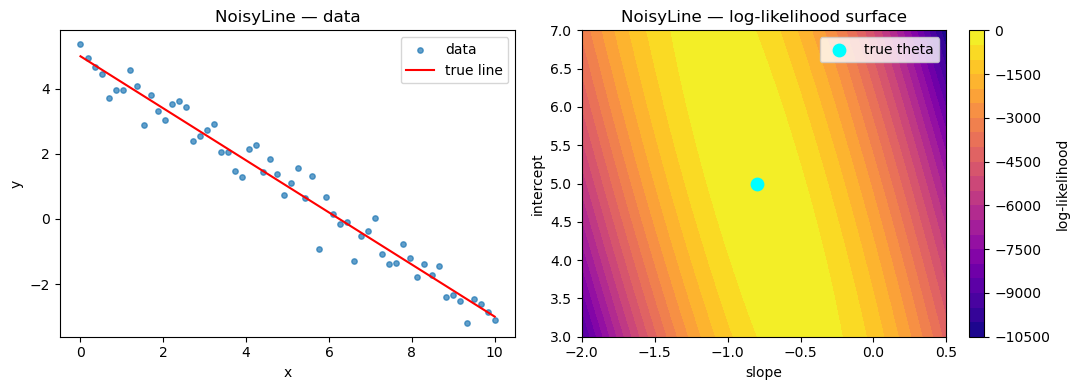

In [6]:
# Log-likelihood surface
slope_grid     = np.linspace(-2, 0.5, 80)
intercept_grid = np.linspace(3, 7, 80)
SL, IC = np.meshgrid(slope_grid, intercept_grid)

loglike_nl = np.array([
    nl.log_prob([s, i], y_obs)
    for s, i in zip(SL.ravel(), IC.ravel())
]).reshape(SL.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(nl.x, y_obs, s=15, alpha=0.7, label="data")
x_fit = np.array([nl.x.min(), nl.x.max()])
axes[0].plot(x_fit, theta_true[0]*x_fit + theta_true[1], "r-", label="true line")
axes[0].set(xlabel="x", ylabel="y", title="NoisyLine — data")
axes[0].legend()

c = axes[1].contourf(SL, IC, loglike_nl, levels=20, cmap="plasma")
plt.colorbar(c, ax=axes[1], label="log-likelihood")
axes[1].scatter(*theta_true, c="cyan", zorder=5, s=80, label="true theta")
axes[1].set(xlabel="slope", ylabel="intercept", title="NoisyLine — log-likelihood surface")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3  MA2Model

Moving Average(2) process: $x_t = w_t + \theta_1 w_{t-1} + \theta_2 w_{t-2}$.

Standard LFI benchmark because the likelihood is intractable — use with
ABC, SBI, or ABC-MCMC (likelihood-free MCMC) methods.
Summary statistics: `[mean, variance, lag-1 autocov, lag-2 autocov]`.

Parameters: `theta = [theta_1, theta_2]` (constrained to the MA(2) invertibility region).

In [7]:
ma2 = MA2Model(n_obs=200)
theta_true = np.array([0.6, 0.2])   # [theta_1, theta_2]

x_raw  = ma2.simulate_raw(theta_true)
x_summ = ma2.simulate(theta_true)
print(f"theta_true   : {theta_true}")
print(f"summary stats: {x_summ.round(4)}  (mean, var, lag-1, lag-2)")
print(f"log_prob     : {ma2.log_prob(theta_true, x_summ)}  (intractable)")

theta_true   : [0.6 0.2]
summary stats: [0.0664 1.4959 0.8529 0.2542]  (mean, var, lag-1, lag-2)
log_prob     : None  (intractable)


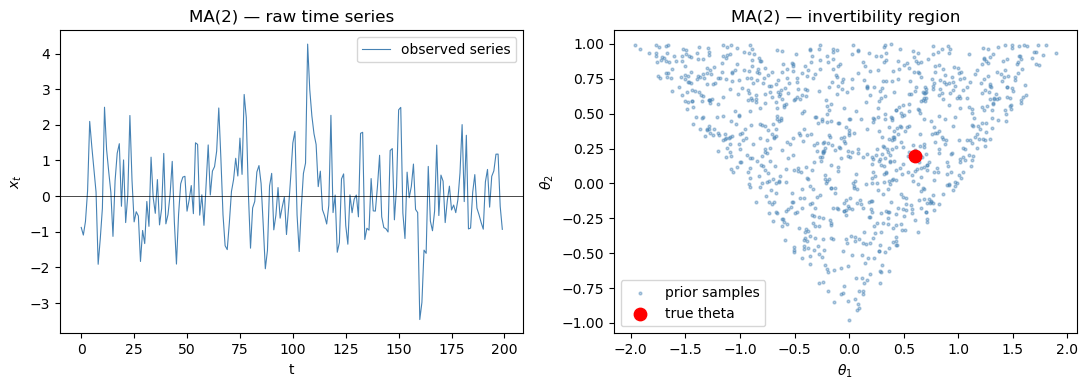

In [8]:
# Theoretical lag-k autocov of MA(2): c(0)=1+t1^2+t2^2, c(1)=t1+t1*t2, c(2)=t2
t1, t2 = theta_true
c0 = 1 + t1**2 + t2**2
theory_lag1 = (t1 + t1*t2) / c0
theory_lag2 = t2 / c0

# Visualise prior samples in (theta_1, theta_2) space and time series
prior_samples = np.array([ma2.sample_prior() for _ in range(1000)])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x_raw, lw=0.8, c="steelblue", label="observed series")
axes[0].axhline(0, c="k", lw=0.5)
axes[0].set(xlabel="t", ylabel=r"$x_t$", title="MA(2) — raw time series")
axes[0].legend()

axes[1].scatter(prior_samples[:, 0], prior_samples[:, 1],
                s=4, alpha=0.4, c="steelblue", label="prior samples")
axes[1].scatter(*theta_true, c="red", zorder=5, s=80, label="true theta")
axes[1].set(xlabel=r"$\theta_1$", ylabel=r"$\theta_2$",
            title="MA(2) — invertibility region")
axes[1].legend()

plt.tight_layout()
plt.show()

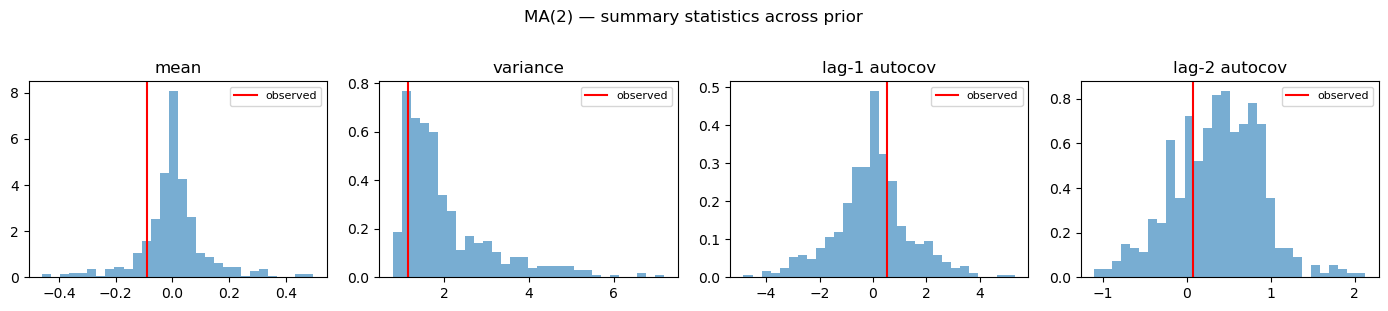

In [9]:
# Distribution of summary statistics across prior samples
n_sim = 500
summ_samples = np.array([ma2.simulate(ma2.sample_prior()) for _ in range(n_sim)])
summ_obs     = ma2.simulate(theta_true)

labels = ["mean", "variance", "lag-1 autocov", "lag-2 autocov"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col, lab in zip(axes, summ_samples.T, labels):
    ax.hist(col, bins=30, density=True, alpha=0.6)
    ax.axvline(summ_obs[labels.index(lab)], c="red", lw=1.5, label="observed")
    ax.set(title=lab)
    ax.legend(fontsize=8)
plt.suptitle("MA(2) — summary statistics across prior", y=1.02)
plt.tight_layout()
plt.show()

---
## 4  PowerLawSpectrum

Simple CMB-like power-law angular power spectrum:

$$C_\ell = A_s \left(\frac{\ell}{\ell_\text{pivot}}\right)^{n_s - 1}$$

with independent Gaussian noise on each band power.

Parameters: `theta = [A_s, n_s]`.

Analytic likelihood suitable for **MCMC** and cosmological Fisher forecasting.

In [10]:
ps = PowerLawSpectrum(noise_sigma=0.05)
theta_true = np.array([1.0, 0.965])   # [A_s, n_s]  (Planck-like n_s)

x_obs = ps.simulate(theta_true)
print(f"theta_true : {theta_true}")
print(f"log_prob   : {ps.log_prob(theta_true, x_obs):.2f}")

theta_true : [1.    0.965]
log_prob   : 31.30


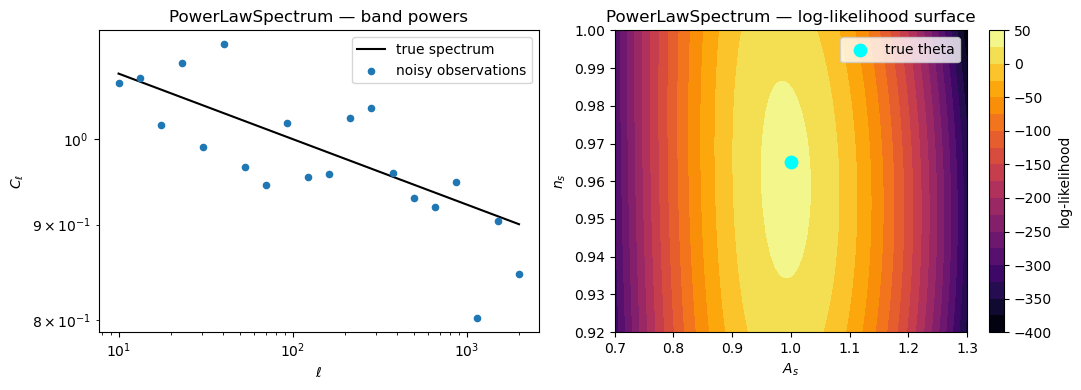

In [11]:
# Log-likelihood surface
As_grid = np.linspace(0.7, 1.3, 80)
ns_grid = np.linspace(0.92, 1.00, 80)
AS, NS  = np.meshgrid(As_grid, ns_grid)

loglike_ps = np.array([
    ps.log_prob([a, n], x_obs)
    for a, n in zip(AS.ravel(), NS.ravel())
]).reshape(AS.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

C_true = ps._spectrum(theta_true)
axes[0].plot(ps.ells, C_true, "k-", label="true spectrum")
axes[0].scatter(ps.ells, x_obs, s=20, c="C0", zorder=5, label="noisy observations")
axes[0].set(xlabel=r"$\ell$", ylabel=r"$C_\ell$",
            title="PowerLawSpectrum — band powers", xscale="log", yscale="log")
axes[0].legend()

c = axes[1].contourf(AS, NS, loglike_ps, levels=20, cmap="inferno")
plt.colorbar(c, ax=axes[1], label="log-likelihood")
axes[1].scatter(*theta_true, c="cyan", zorder=5, s=80, label="true theta")
axes[1].set(xlabel=r"$A_s$", ylabel=r"$n_s$",
            title="PowerLawSpectrum — log-likelihood surface")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5  LotkaVolterra

Predator-prey ODE system with Gaussian noise on observations:

$$
\frac{dx}{dt} = \alpha x - \beta x y, \qquad
\frac{dy}{dt} = \delta x y - \gamma y
$$

Parameters: `theta = [alpha, beta, delta, gamma]`.

Analytic Gaussian likelihood enables **MCMC** sampling and Fisher forecasting.
Non-linear dynamics also make it a useful SBI benchmark.

In [12]:
from psiphy.toy_models import LotkaVolterra

lv = LotkaVolterra(noise_sigma=0.5)
theta_true = np.array([1.0, 0.1, 0.075, 1.5])  # [alpha, beta, delta, gamma]

x_obs  = lv.simulate(theta_true)
traj   = lv.noiseless(theta_true)  # shape (2, n_obs)
print(f"theta_true : {theta_true}")
print(f"log_prob   : {lv.log_prob(theta_true, x_obs):.2f}")

theta_true : [1.    0.1   0.075 1.5  ]
log_prob   : -18.09


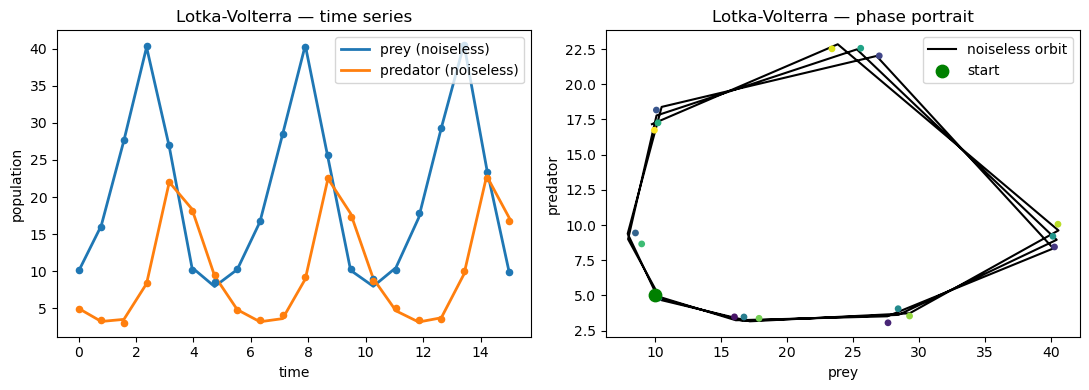

In [13]:
n_obs = len(lv.t_obs)
prey_obs = x_obs[:n_obs]
pred_obs = x_obs[n_obs:]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- time series ---
axes[0].plot(lv.t_obs, traj[0], "C0-",  lw=2, label="prey (noiseless)")
axes[0].plot(lv.t_obs, traj[1], "C1-",  lw=2, label="predator (noiseless)")
axes[0].scatter(lv.t_obs, prey_obs, s=20, c="C0", zorder=5)
axes[0].scatter(lv.t_obs, pred_obs, s=20, c="C1", zorder=5)
axes[0].set(xlabel="time", ylabel="population",
            title="Lotka-Volterra — time series")
axes[0].legend()

# --- phase portrait ---
axes[1].plot(traj[0], traj[1], "k-", lw=1.5, label="noiseless orbit")
axes[1].scatter(prey_obs, pred_obs, s=15, c=lv.t_obs, cmap="viridis", zorder=5)
axes[1].scatter(*traj[:, 0], c="green", s=80, zorder=6, label="start")
axes[1].set(xlabel="prey", ylabel="predator",
            title="Lotka-Volterra — phase portrait")
axes[1].legend()

plt.tight_layout()
plt.show()

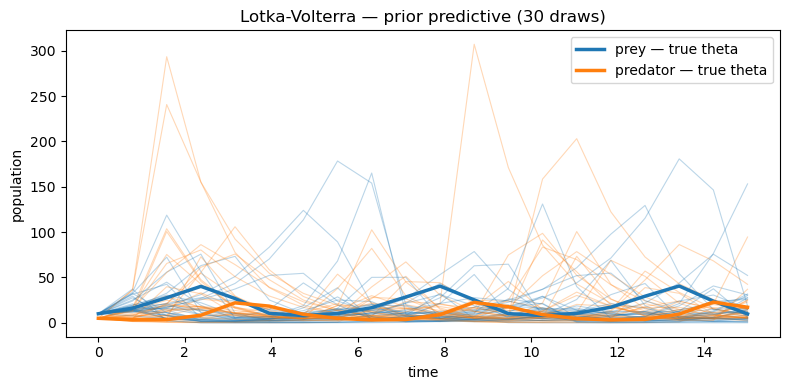

In [14]:
# Prior predictive: how much do trajectories vary across the prior?
fig, ax = plt.subplots(figsize=(8, 4))

for _ in range(30):
    theta = lv.sample_prior()
    traj_i = lv.noiseless(theta)
    if traj_i is not None:
        ax.plot(lv.t_obs, traj_i[0], alpha=0.3, lw=0.8, c="C0")
        ax.plot(lv.t_obs, traj_i[1], alpha=0.3, lw=0.8, c="C1")

ax.plot(lv.t_obs, traj[0], "C0-", lw=2.5, label="prey — true theta")
ax.plot(lv.t_obs, traj[1], "C1-", lw=2.5, label="predator — true theta")
ax.set(xlabel="time", ylabel="population",
       title="Lotka-Volterra — prior predictive (30 draws)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

| Model | Parameters | Analytic likelihood | Typical use |
|---|---|---|---|
| `GaussianSignal` | mean, sigma | yes | MCMC, Fisher, SBI sanity checks |
| `NoisyLine` | slope, intercept | yes | MCMC, Fisher matrix tutorials |
| `MA2Model` | theta_1, theta_2 | no (intractable) | ABC-MCMC, LFI / SBI benchmarks |
| `PowerLawSpectrum` | A_s, n_s | yes | MCMC, cosmological Fisher forecasts |
| `LotkaVolterra` | alpha, beta, delta, gamma | yes | MCMC, dynamical-system SBI / Fisher |